# Adam: A Method for Stochastic Optimization (Implementation)

This notebook implements and analyzes the **Adam** optimizer as proposed by **Kingma and Ba (2014)**.

### Key Intuition
Adam computes individual adaptive learning rates for different parameters from estimates of first and second moments of the gradients. It combines the benefits of **Momentum** and **RMSProp**.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from model import Adam

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 1. The Mathematical Framework

The update rules for Adam are:
1. $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$
2. $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$
3. $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$
4. $\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$
5. $\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

In [2]:
def beale(x, y):
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

def grad_beale(params):
    x, y = params[0], params[1]
    dx = 2*(1.5 - x + x*y)*(y - 1) + 2*(2.25 - x + x*y**2)*(y**2 - 1) + 2*(2.625 - x + x*y**3)*(y**3 - 1)
    dy = 2*(1.5 - x + x*y)*x + 2*(2.25 - x + x*y**2)*(2*x*y) + 2*(2.625 - x + x*y**3)*(3*x*y**2)
    return np.array([dx, dy])

In [3]:
iterations = 500
start_pos = np.array([1.0, 1.0])

adam = Adam(params_shape_list=[(2,)], lr=0.01)
w_adam = start_pos.copy()
path_adam = [w_adam.copy()]

w_sgd = start_pos.copy()
path_sgd = [w_sgd.copy()]
lr_sgd = 0.0005

for _ in range(iterations):
    g_adam = np.clip(grad_beale(w_adam), -1.0, 1.0)
    w_adam = adam.step([w_adam], [g_adam])[0]
    path_adam.append(w_adam.copy())

    g_sgd = np.clip(grad_beale(w_sgd), -1.0, 1.0)
    w_sgd -= lr_sgd * g_sgd
    path_sgd.append(w_sgd.copy())

path_adam = np.array(path_adam)
path_sgd = np.array(path_sgd)

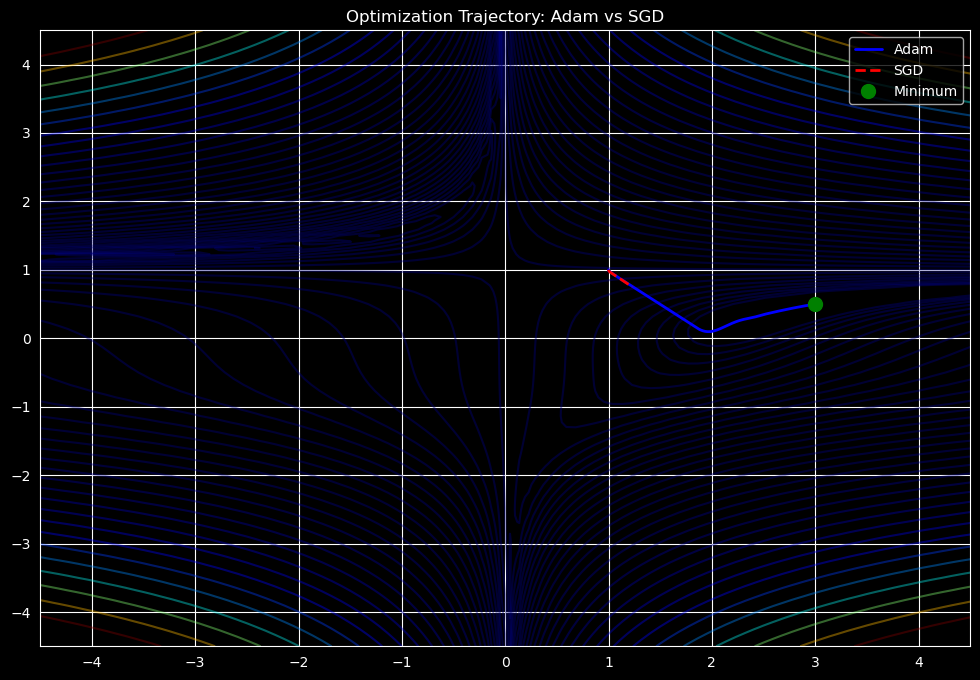

In [4]:
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = beale(X, Y)

plt.contour(X, Y, Z, levels=np.logspace(0, 5, 35), cmap='jet', alpha=0.4)
plt.plot(path_adam[:, 0], path_adam[:, 1], color='blue', label='Adam', linewidth=2)
plt.plot(path_sgd[:, 0], path_sgd[:, 1], color='red', linestyle='--', label='SGD', linewidth=2)
plt.plot(3, 0.5, 'go', markersize=10, label='Minimum')
plt.title("Optimization Trajectory: Adam vs SGD")
plt.legend()
plt.show()

## 3. Findings
* **Stability**: Adam is significantly more robust to the initialization and learning rate. While SGD often explodes on the Beale function (Polynomial terms), Adam's adaptive scaling ($\sqrt{v_t}$) keeps updates in check.
* **Bias Correction**: Critical for the first few steps. Without it, the optimizer is sluggish as $m_t$ and $v_t$ start at 0.